# **1. Perkenalan Dataset**

**Nama:** Riski Pratama

**Dataset:** Forest Covertype (dari `sklearn.datasets`)

Dataset Covertype berisi data kartografis dari area hutan di Roosevelt National Forest, Colorado.
Tujuannya memprediksi jenis tutupan hutan (cover type) berdasarkan 54 fitur.

- **Sumber:** UCI ML Repository via `sklearn.datasets.fetch_covtype`
- **Jumlah sampel (subsample):** 10.000
- **Jumlah fitur:** 54 (10 kontinu + 44 biner)
- **Jumlah kelas target:** 7 (jenis tutupan hutan)

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka yang dibutuhkan untuk analisis data, visualisasi, dan preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Dataset Covertype dimuat dari sklearn, kemudian disubsample menjadi 10.000 baris
menggunakan stratified sampling agar distribusi kelas tetap proporsional.

In [2]:
covtype = fetch_covtype(as_frame=True)
df_full = covtype.frame.copy()
target_col = df_full.columns[-1]
df_full = df_full.rename(columns={target_col: 'target'})
print(f'Full dataset shape: {df_full.shape}')
print(f'Kelas target: {sorted(df_full["target"].unique())}')

df = resample(df_full, n_samples=10000, random_state=42, stratify=df_full['target'])
df = df.reset_index(drop=True)
print(f'\nSubsampled dataset shape: {df.shape}')

feature_names = [c for c in df.columns if c != 'target']
print(f'Jumlah fitur: {len(feature_names)}')
print('\n5 baris pertama:')
df.head()

Full dataset shape: (581012, 55)
Kelas target: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]

Subsampled dataset shape: (10000, 55)
Jumlah fitur: 54

5 baris pertama:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,target
0,3260.0,346.0,8.0,216.0,72.0,1471.0,205.0,228.0,161.0,2850.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2939.0,333.0,14.0,108.0,31.0,4357.0,187.0,221.0,173.0,2389.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,2835.0,293.0,14.0,67.0,13.0,2464.0,181.0,236.0,195.0,2315.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2100.0,34.0,33.0,150.0,56.0,283.0,194.0,149.0,68.0,395.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2877.0,278.0,13.0,0.0,0.0,2066.0,185.0,242.0,196.0,1006.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, dilakukan EDA untuk memahami karakteristik dataset
dan menentukan langkah selanjutnya dalam preprocessing.

In [3]:
CONTINUOUS_FEATURES = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am',
    'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

COVER_MAP = {
    1: 'Spruce/Fir', 2: 'Lodgepole Pine', 3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow', 5: 'Aspen', 6: 'Douglas-fir', 7: 'Krummholz'
}
df['cover_name'] = df['target'].map(COVER_MAP)

In [4]:
print('=' * 50)
print('INFORMASI DASAR DATASET')
print('=' * 50)
print(f'Shape: {df.shape}')
print(f'\nTipe data (fitur kontinu):')
print(df[CONTINUOUS_FEATURES].dtypes)
print(f'\nStatistik deskriptif:')
df[CONTINUOUS_FEATURES].describe()

INFORMASI DASAR DATASET
Shape: (10000, 56)

Tipe data (fitur kontinu):
Elevation                             float64
Aspect                                float64
Slope                                 float64
Horizontal_Distance_To_Hydrology      float64
Vertical_Distance_To_Hydrology        float64
Horizontal_Distance_To_Roadways       float64
Hillshade_9am                         float64
Hillshade_Noon                        float64
Hillshade_3pm                         float64
Horizontal_Distance_To_Fire_Points    float64
dtype: object

Statistik deskriptif:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2957.066800,154.497100,14.299800,268.800200,47.657600,2331.565100,211.816500,222.990400,142.388700,1971.857500
std,283.427332,111.825693,7.587389,212.818472,58.688362,1547.170429,27.511076,20.013225,38.837004,1322.724853
min,1901.000000,0.000000,0.000000,0.000000,-155.000000,0.000000,67.000000,53.000000,0.000000,0.000000
25%,2811.000000,57.000000,9.000000,108.000000,7.000000,1103.000000,198.000000,212.000000,119.000000,1018.000000
50%,2997.000000,126.000000,13.000000,218.000000,31.000000,1974.000000,218.000000,226.000000,143.000000,1705.000000
75%,3159.000000,260.000000,19.000000,379.000000,71.000000,3290.000000,231.000000,237.000000,169.000000,2538.000000
max,3797.000000,359.000000,60.000000,1301.000000,574.000000,6931.000000,254.000000,254.000000,252.000000,7173.000000


In [5]:
print('=' * 50)
print('CEK MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('Tidak ada missing values.')

CEK MISSING VALUES
Total missing values: 0
Tidak ada missing values.


In [6]:
print('=' * 50)
print('CEK DUPLIKASI')
print('=' * 50)
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

CEK DUPLIKASI
Jumlah baris duplikat: 96


DISTRIBUSI TARGET
cover_name
Lodgepole Pine       4876
Spruce/Fir           3646
Ponderosa Pine        615
Krummholz             353
Douglas-fir           299
Aspen                 164
Cottonwood/Willow      47
Name: count, dtype: int64


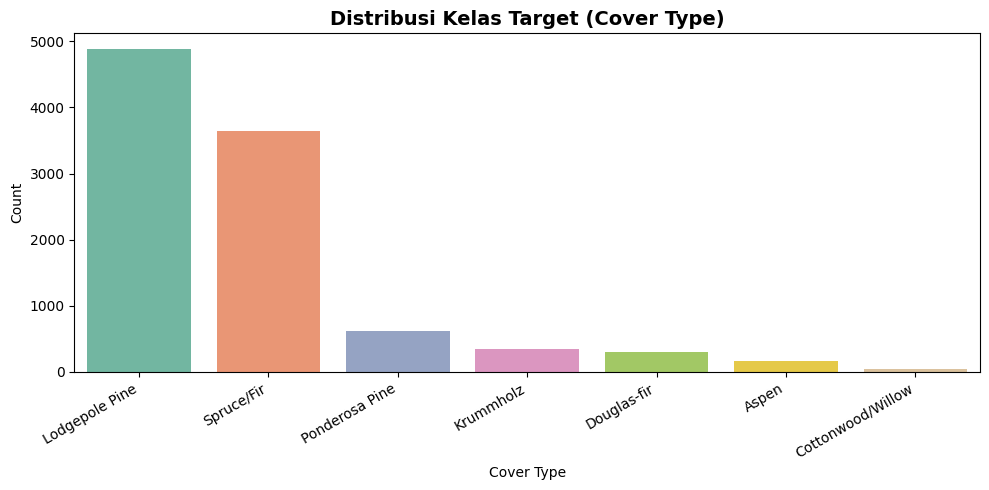

In [7]:
print('=' * 50)
print('DISTRIBUSI TARGET')
print('=' * 50)
print(df['cover_name'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cover_name', palette='Set2',
              order=df['cover_name'].value_counts().index)
plt.title('Distribusi Kelas Target (Cover Type)', fontsize=14, fontweight='bold')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

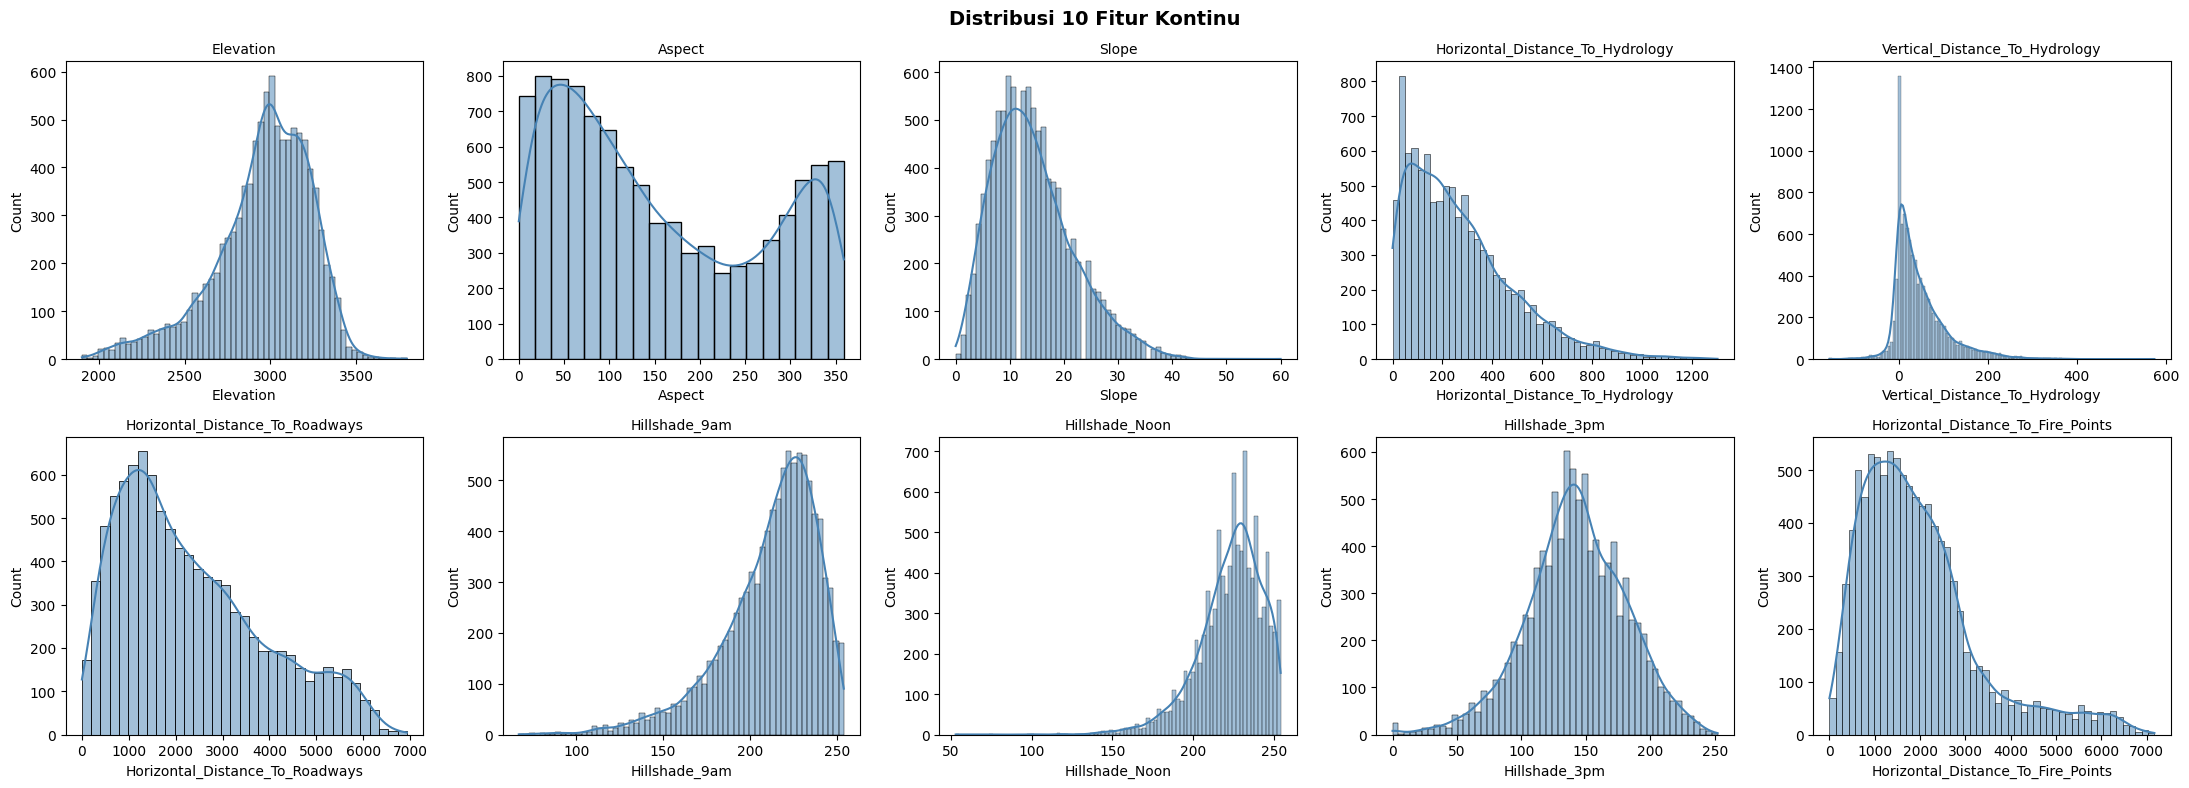

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i // 5, i % 5]
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
plt.suptitle('Distribusi 10 Fitur Kontinu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

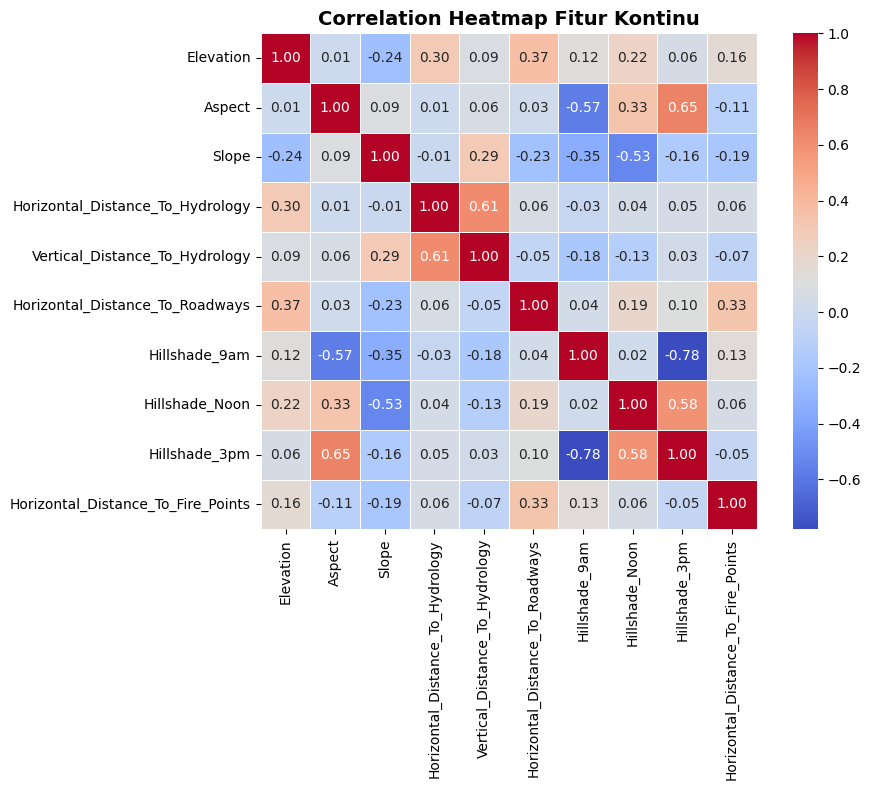

In [9]:
plt.figure(figsize=(10, 8))
corr = df[CONTINUOUS_FEATURES].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap Fitur Kontinu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

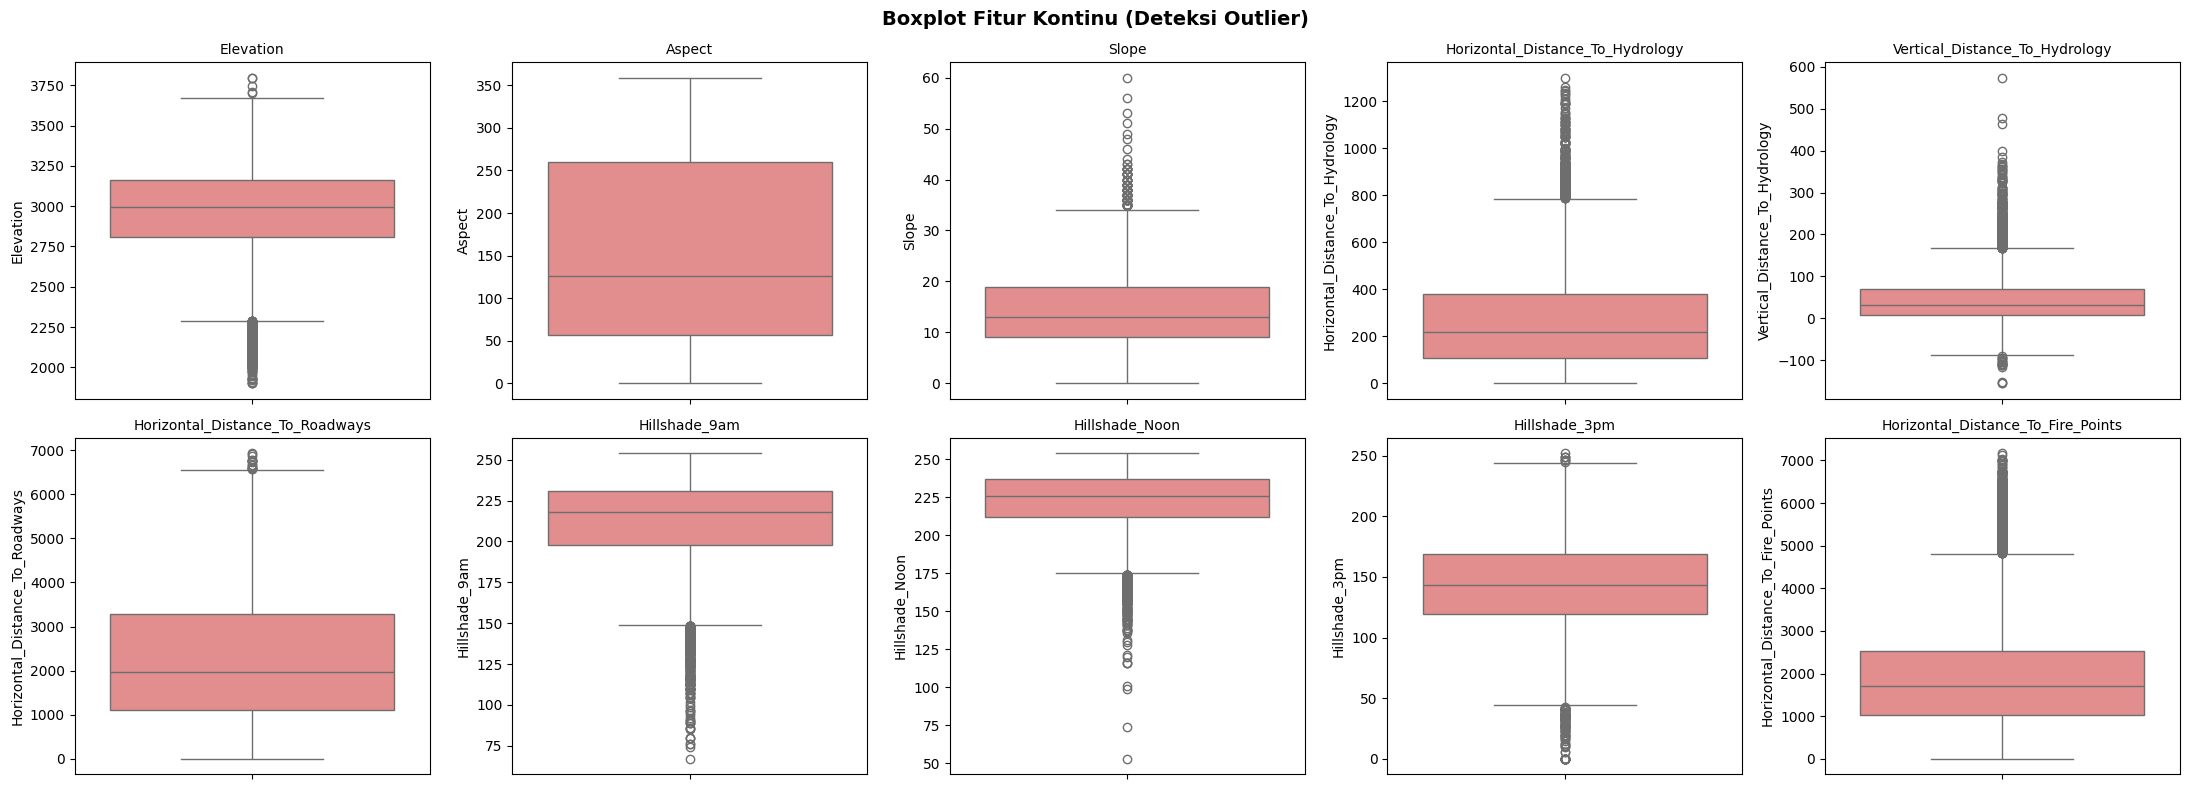

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i // 5, i % 5]
    sns.boxplot(data=df, y=col, ax=ax, color='lightcoral')
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplot Fitur Kontinu (Deteksi Outlier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Menghapus Data Duplikat
2. Deteksi Outlier (IQR Method) pada fitur kontinu
3. Split Features & Target
4. Train-Test Split (80:20)
5. Standarisasi Fitur (StandardScaler)
6. Simpan Data Hasil Preprocessing ke CSV

In [11]:
print('=' * 50)
print('1. MENGHAPUS DATA DUPLIKAT')
print('=' * 50)
df_clean = df.drop(columns=['cover_name']).drop_duplicates()
print(f'Sebelum: {len(df)} baris')
print(f'Sesudah: {len(df_clean)} baris')
print(f'Dihapus: {len(df) - len(df_clean)} baris duplikat')

1. MENGHAPUS DATA DUPLIKAT
Sebelum: 10000 baris
Sesudah: 9904 baris
Dihapus: 96 baris duplikat


In [12]:
print('=' * 50)
print('2. DETEKSI OUTLIER (IQR METHOD)')
print('=' * 50)
for col in CONTINUOUS_FEATURES:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outlier (range: [{lower:.2f}, {upper:.2f}])')

2. DETEKSI OUTLIER (IQR METHOD)
Elevation: 322 outlier (range: [2289.00, 3681.00])
Aspect: 0 outlier (range: [-247.50, 564.50])
Slope: 138 outlier (range: [-6.00, 34.00])
Horizontal_Distance_To_Hydrology: 266 outlier (range: [-303.00, 793.00])
Vertical_Distance_To_Hydrology: 516 outlier (range: [-89.00, 167.00])
Horizontal_Distance_To_Roadways: 17 outlier (range: [-2174.50, 6565.50])
Hillshade_9am: 347 outlier (range: [148.50, 280.50])
Hillshade_Noon: 238 outlier (range: [174.50, 274.50])
Hillshade_3pm: 122 outlier (range: [44.00, 244.00])
Horizontal_Distance_To_Fire_Points: 527 outlier (range: [-1268.00, 4820.00])


In [13]:
print('=' * 50)
print('3. SPLIT FEATURES & TARGET')
print('=' * 50)
X = df_clean[feature_names]
y = df_clean['target']
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Target classes: {sorted(y.unique())}')

3. SPLIT FEATURES & TARGET
Features shape: (9904, 54)
Target shape: (9904,)
Target classes: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]


In [14]:
print('=' * 50)
print('4. TRAIN-TEST SPLIT (80:20)')
print('=' * 50)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

4. TRAIN-TEST SPLIT (80:20)
X_train: (7923, 54), X_test: (1981, 54)
y_train: (7923,), y_test: (1981,)


In [15]:
print('=' * 50)
print('5. STANDARISASI FITUR (StandardScaler)')
print('=' * 50)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f'Mean sebelum scaling (5 fitur pertama): {X_train[CONTINUOUS_FEATURES[:5]].mean().values.round(2)}')
print(f'Mean setelah scaling (5 fitur pertama): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'Std setelah scaling (5 fitur pertama):  {X_train_scaled[:, :5].std(axis=0).round(4)}')

5. STANDARISASI FITUR (StandardScaler)
Mean sebelum scaling (5 fitur pertama): [2957.06  154.23   14.36  268.98   48.04]
Mean setelah scaling (5 fitur pertama): [ 0. -0.  0.  0. -0.]
Std setelah scaling (5 fitur pertama):  [1. 1. 1. 1. 1.]


In [16]:
import os
print('=' * 50)
print('6. SIMPAN DATA PREPROCESSING')
print('=' * 50)

output_dir = 'covtype_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
train_df['target'] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
test_df['target'] = y_test.values

train_path = os.path.join(output_dir, 'covtype_train_preprocessed.csv')
test_path = os.path.join(output_dir, 'covtype_test_preprocessed.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f'Train preprocessed: {train_df.shape} -> {train_path}')
print(f'Test preprocessed: {test_df.shape} -> {test_path}')

print('\n' + '=' * 50)
print('PREVIEW DATA PREPROCESSING (TRAIN)')
print('=' * 50)
train_df.head()

6. SIMPAN DATA PREPROCESSING


Train preprocessed: (7923, 55) -> covtype_preprocessing\covtype_train_preprocessed.csv
Test preprocessed: (1981, 55) -> covtype_preprocessing\covtype_test_preprocessed.csv

PREVIEW DATA PREPROCESSING (TRAIN)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,target
0,-2.105194,-0.566036,-0.178247,-0.695698,-0.646704,-1.298927,1.020783,-0.249036,-0.931345,-0.971684,...,-0.311064,-0.299201,-0.059553,-0.049029,-0.011235,-0.022475,-0.168206,-0.162976,-0.130164,3
1,1.332609,0.177006,0.346267,-0.975887,-0.969716,-0.113081,0.587908,1.149309,0.039653,1.258866,...,3.214773,-0.299201,-0.059553,-0.049029,-0.011235,-0.022475,-0.168206,-0.162976,-0.130164,1
2,-0.550249,-0.700321,2.182066,0.341003,1.767384,-0.808951,1.020783,-2.845963,-2.796682,-0.933069,...,-0.311064,-0.299201,-0.059553,-0.049029,-0.011235,-0.022475,-0.168206,-0.162976,-0.130164,2
3,-0.525568,-0.503370,0.346267,0.429730,0.186327,0.516330,1.237221,-0.498741,-1.340186,0.439635,...,-0.311064,-0.299201,-0.059553,-0.049029,-0.011235,-0.022475,-0.168206,-0.162976,-0.130164,2
4,0.087948,-0.959938,-0.702761,0.784637,-0.935714,0.697465,0.407543,-0.149155,-0.292531,2.781484,...,-0.311064,-0.299201,-0.059553,-0.049029,-0.011235,-0.022475,-0.168206,-0.162976,-0.130164,2
